In [9]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [11]:
from google.colab import files

uploaded = files.upload()

Saving Retail sales data for python.xlsx to Retail sales data for python.xlsx


In [21]:
import pandas as pd

df = pd.read_excel('/content/Retail sales data for python.xlsx')

First 5 Rows

In [13]:
print(df.head())

  Order_ID Order_Date   Customer_Name       City Region     Product  \
0  ORD0001 2025-06-23  Patricia Glass       Pune  North    Keyboard   
1  ORD0002 2025-06-12     Roger Lopez     Mumbai  South         Pen   
2  ORD0003 2025-05-05     Diane Price       Pune   East  Headphones   
3  ORD0004 2025-02-20   Joseph Rivera      Delhi   East       Table   
4  ORD0005 2025-11-12   Teresa Flores  Bengaluru  North    Keyboard   

          Category  Quantity     Sales   Profit  
0      Electronics         4  18880.01  4559.07  
1  Office Supplies        10  35912.71  2190.70  
2      Electronics        10  44225.01  9087.29  
3        Furniture         5  38506.42  3129.78  
4      Electronics         5  23690.24  3314.65  


Dataset Size

In [14]:
print(df.shape)

(800, 10)


Dataset Information

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       800 non-null    object        
 1   Order_Date     800 non-null    datetime64[ns]
 2   Customer_Name  800 non-null    object        
 3   City           800 non-null    object        
 4   Region         800 non-null    object        
 5   Product        800 non-null    object        
 6   Category       800 non-null    object        
 7   Quantity       800 non-null    int64         
 8   Sales          800 non-null    float64       
 9   Profit         800 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 62.6+ KB


Missing Values Check

In [16]:
print(df.isnull().sum())

Order_ID         0
Order_Date       0
Customer_Name    0
City             0
Region           0
Product          0
Category         0
Quantity         0
Sales            0
Profit           0
dtype: int64


Total Duplicate Rows Count

In [23]:
duplicates = df.duplicated().sum()

print("Total Duplicate Records:", duplicates)

Total Duplicate Records: 0


Duplicate Rows

In [24]:
duplicate_rows = df[df.duplicated()]

print(duplicate_rows)

Empty DataFrame
Columns: [Order_ID, Order_Date, Customer_Name, City, Region, Product, Category, Quantity, Sales, Profit]
Index: []


Summary Statistics

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       800 non-null    object        
 1   Order_Date     800 non-null    datetime64[ns]
 2   Customer_Name  800 non-null    object        
 3   City           800 non-null    object        
 4   Region         800 non-null    object        
 5   Product        800 non-null    object        
 6   Category       800 non-null    object        
 7   Quantity       800 non-null    int64         
 8   Sales          800 non-null    float64       
 9   Profit         800 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 62.6+ KB


8. Region Wise Sales Analysis

In [26]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
East     5604977.73
South    5243724.76
North    5132836.93
West     4715379.81
Name: Sales, dtype: float64


Chart

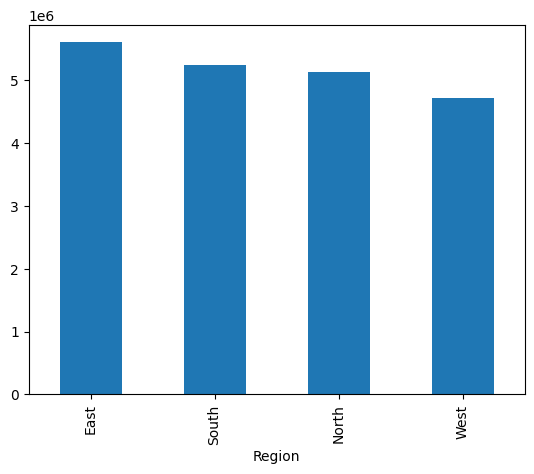

In [27]:
import matplotlib.pyplot as plt

region_sales.plot(kind="bar")
plt.show()

In [28]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
City,0
Region,0
Product,0
Category,0
Quantity,0
Sales,0
Profit,0


In [29]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Region
East     5604977.73
South    5243724.76
North    5132836.93
West     4715379.81
Name: Sales, dtype: float64


Profit by Category

In [30]:
profit_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print(profit_category)

Category
Electronics        1863938.43
Office Supplies     646681.58
Furniture           615239.14
Name: Profit, dtype: float64


Chart

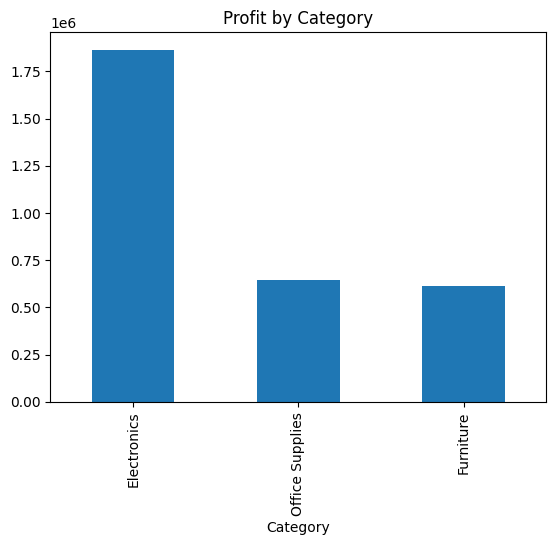

In [31]:
import matplotlib.pyplot as plt

profit_category.plot(kind="bar")
plt.title("Profit by Category")
plt.show()

Top 10 Products by Sales

In [32]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_products)

Product
Monitor       2483996.77
Keyboard      2322892.16
Pen           2287228.49
Headphones    2098449.02
Chair         2047477.55
Table         1993222.33
Laptop        1935691.21
Printer       1858515.80
Notebook      1850803.07
Mouse         1818642.83
Name: Sales, dtype: float64


Chart

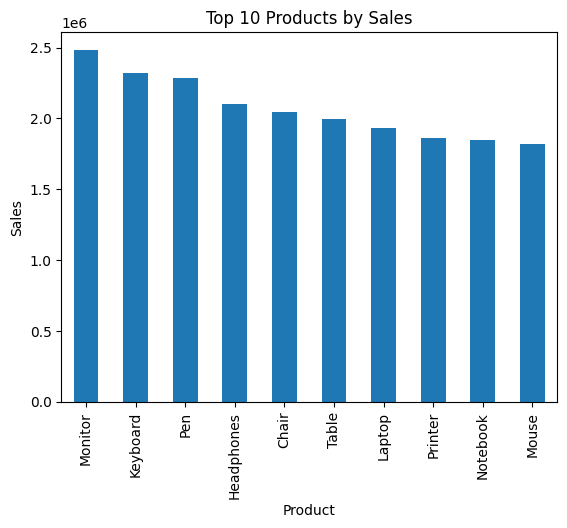

In [33]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

Monthly Sales Trend

In [34]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = df.groupby(df["Order_Date"].dt.month)["Sales"].sum()

print(monthly_sales)

Order_Date
1     2527047.27
2     2707914.40
3     2810315.16
4     2446723.55
5     2015014.28
6     1366632.15
7      934668.39
8     1293847.21
9     1188852.86
10    1300135.09
11    1031974.35
12    1073794.52
Name: Sales, dtype: float64


Line Chart

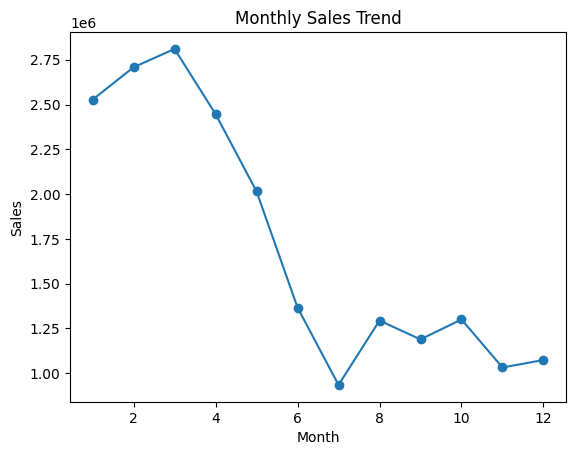

In [35]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Top 10 Customers by Sales

In [36]:
top_customers = df.groupby("Customer_Name")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer_Name
David Vargas         58521.16
Christine Collier    49889.57
Luis Carpenter       49851.48
Michael Thomas       49833.63
Tracey Smith         49829.68
Craig Hansen         49798.06
Chris Jones          49745.51
Megan Lopez          49700.48
Tammy Bowers         49663.55
Jacob Miller         49662.01
Name: Sales, dtype: float64


Correlation Analysis

In [37]:
print(df[["Sales","Profit","Quantity"]].corr())

             Sales    Profit  Quantity
Sales     1.000000  0.787321 -0.019373
Profit    0.787321  1.000000 -0.005301
Quantity -0.019373 -0.005301  1.000000


# Superstore Sales Analysis - Key Insights

## 1.** Region Wise Sales**

East Region recorded the highest sales (5.60 million).
South Region generated the second-highest sales (5.24 million).
North Region achieved sales of 5.13 million.
West Region had the lowest sales (4.72 million).
East Region was the best-performing region in terms of revenue.

## 2. **Profit by Category**

Electronics generated the highest profit (1.86 million).
Office Supplies contributed a profit of 0.65 million.
Furniture generated the lowest profit (0.62 million).
Electronics was the most profitable category for the business.

## 3. **Top Products by Sales**

Monitor was the highest-selling product with sales of 2.48 million.
Keyboard and Pen were also among the top-performing products.
Headphones, Chair, Table, and Laptop generated strong sales.
These products contributed significantly to overall revenue.

## 4. **Monthly Sales Trend**

March recorded the highest sales (2.81 million).
February and January also showed strong sales performance.
July recorded the lowest sales (0.93 million).
Sales were strongest in the first quarter of the year and declined during the middle months.

## 5. **Top Customers**

David Vargas was the highest-value customer with total sales of 58,521.
Christine Collier and Luis Carpenter were among the top customers.
The top 10 customers contributed a significant share of total revenue.

## **Conclusion**

The analysis shows that East Region and Electronics category were the strongest contributors to business performance. Monitor was the best-selling product, while March was the highest-performing month. The company can focus on high-performing regions, products, and customers to increase future sales and profitability.
